this notebook is to test, evaluate and demonstrate different optimizers  

we use a simple standard CNN model a Convolutional, Pooling and a Flatten layer (along with Dense layers and Dropouts - refer to model definition for exact details)   

and we train on the MNIST dataset provided by TF:  
 MNIST - Sample ML dataset of Handwritten Digits  
https://www.tensorflow.org/datasets/catalog/mnist  

We try out AdaDelta, AdaGrad, Adam, RMSProp, SGC, SGD with momentum in this notebook  

the trainining and hyperparameters are kept simple - for the sake of visualization


# Imports

In [1]:
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D
# from tensorflow.keras import backend as K

from tensorflow.keras.callbacks import TensorBoard

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import time
import datetime
from tqdm import tqdm 


# Load MNIST

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data() 
print(x_train.shape, y_train.shape) 

(60000, 28, 28) (60000,)


# Reshape data for CNN input (batch, width, height, channel)

In [3]:
# Reshape data for CNN input (batch, width, height, channel)
# Normalize input data to floats between 0 and 1
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype("float32") / 255
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype("float32") / 255
input_shape = (28, 28, 1)

# Convert class vectors to binary categorical matrices
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [10]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28, 1) (60000, 10)
(10000, 28, 28, 1) (10000, 10)


# Define Model

In [4]:
input_shape = (28, 28, 1)
batch_size = 64
num_classes = 10
epochs = 10

In [5]:
def build_model(optimizer):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(32, kernel_size=(3,3), activation='relu'),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )
    return model

# Define Optimizer List

Default Learning Rate  
- Adadelta: learning rate = 0.0010000000474974513
- Adagrad: learning rate = 0.0010000000474974513
- Adam: learning rate = 0.0010000000474974513
- RMSprop: learning rate = 0.0010000000474974513
- SGD: learning rate = 0.009999999776482582
- SGD_Momentum: learning rate = 0.009999999776482582

In [6]:
optimizers_to_test = {
    'Adadelta': tf.keras.optimizers.Adadelta(learning_rate=0.2),
    'Adagrad': tf.keras.optimizers.Adagrad(learning_rate=0.2),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.2),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=0.2),
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.2),
    'SGD_Momentum': tf.keras.optimizers.SGD(momentum=0.9, learning_rate=0.2),
}

# Training

In [7]:
class CustomEpochLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        print(
            f"Epoch {epoch+1:2d} - "
            f"loss: {logs.get('loss'):.4f} - acc: {logs.get('accuracy'):.4f} - "
            f"val_loss: {logs.get('val_loss'):.4f} - val_acc: {logs.get('val_accuracy'):.4f}"
        )

In [8]:
x_train_small = x_train[:10000]
y_train_small = y_train[:10000]

In [9]:
records = []

for name, opt in optimizers_to_test.items():

    print(f"--- Training with {name} ---")

    model = build_model(opt)
    print("  > Model built.")

    log_dir = f"logs/{name}_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

    start_time = time.time()
    hist = model.fit(
        x_train_small, y_train_small,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(x_test, y_test),
        callbacks=[tensorboard_callback, CustomEpochLogger()],
        verbose=0
    )
    elapsed = time.time() - start_time

    print(f"  > Finished in {elapsed:.2f} sec.")

    for epoch in range(epochs):
        records.append({
            'optimizer': name,
            'epoch': epoch + 1,
            'train_loss': hist.history['loss'][epoch],
            'train_acc': hist.history['accuracy'][epoch],
            'val_loss': hist.history['val_loss'][epoch],
            'val_acc': hist.history['val_accuracy'][epoch],
            'total_time': elapsed
        })


--- Training with Adadelta ---
  > Model built.
Epoch  1 - loss: 0.9379 - acc: 0.7322 - val_loss: 0.4038 - val_acc: 0.8883
Epoch  2 - loss: 0.4271 - acc: 0.8714 - val_loss: 0.2990 - val_acc: 0.9161
Epoch  3 - loss: 0.3523 - acc: 0.8956 - val_loss: 0.2625 - val_acc: 0.9237
Epoch  4 - loss: 0.3082 - acc: 0.9092 - val_loss: 0.2408 - val_acc: 0.9289
Epoch  5 - loss: 0.2706 - acc: 0.9208 - val_loss: 0.2201 - val_acc: 0.9338
Epoch  6 - loss: 0.2562 - acc: 0.9255 - val_loss: 0.2003 - val_acc: 0.9410
Epoch  7 - loss: 0.2312 - acc: 0.9326 - val_loss: 0.1848 - val_acc: 0.9456
Epoch  8 - loss: 0.2191 - acc: 0.9346 - val_loss: 0.1771 - val_acc: 0.9479
Epoch  9 - loss: 0.2004 - acc: 0.9418 - val_loss: 0.1648 - val_acc: 0.9509
Epoch 10 - loss: 0.1902 - acc: 0.9446 - val_loss: 0.1625 - val_acc: 0.9506
  > Finished in 246.52 sec.
--- Training with Adagrad ---
  > Model built.
Epoch  1 - loss: 0.6693 - acc: 0.7873 - val_loss: 0.2068 - val_acc: 0.9352
Epoch  2 - loss: 0.2177 - acc: 0.9329 - val_loss: 0.

In [11]:
# To see training Progress run this on CLI
# tensorboard --logdir=logs/
# http://localhost:6006

In [12]:
df = pd.DataFrame(records)
df.to_csv('./data/optimizer_epoch_log.csv', index=False)

# Visualize

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   optimizer   60 non-null     object 
 1   epoch       60 non-null     int64  
 2   train_loss  60 non-null     float64
 3   train_acc   60 non-null     float64
 4   val_loss    60 non-null     float64
 5   val_acc     60 non-null     float64
 6   total_time  60 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 3.4+ KB


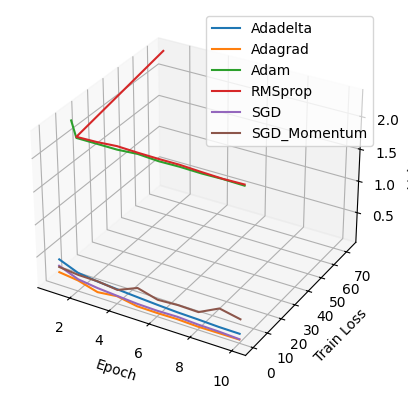

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss')
ax.set_zlabel('Val Loss')
for name in optimizers_to_test.keys():
    subset = df[df['optimizer'] == name]
    ax.plot(subset['epoch'], subset['train_loss'], subset['val_loss'], label=name)
    ax.legend()
plt.show()


In [15]:
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D

import os

log_path = "./data/optimizer_epoch_log.csv"  
if os.path.exists(log_path):
    df = pd.read_csv(log_path)

# Create 3D animated contour plot
optimizers = df['optimizer'].unique()
epoch_count = df['epoch'].max()
epoch_grid = np.arange(1, epoch_count + 1)

# Map optimizer names to numerical indices
opt_to_idx = {opt: i for i, opt in enumerate(optimizers)}
df['opt_idx'] = df['optimizer'].map(opt_to_idx)

# Create a 2D grid: (epoch, optimizer) -> val_loss
loss_matrix = np.zeros((len(optimizers), epoch_count))
for i, opt in enumerate(optimizers):
    loss_matrix[i] = df[df['optimizer'] == opt].sort_values('epoch')['val_loss'].values

X, Y = np.meshgrid(epoch_grid, np.arange(len(optimizers)))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

def update(frame):
    ax.clear()
    Z = loss_matrix[:, :frame+1]
    X_frame, Y_frame = np.meshgrid(epoch_grid[:frame+1], np.arange(len(optimizers)))
    surf = ax.plot_surface(X_frame, Y_frame, Z, cmap='viridis', edgecolor='none')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Optimizer')
    ax.set_yticks(range(len(optimizers)))
    ax.set_yticklabels(optimizers)
    ax.set_zlabel('Validation Loss')
    ax.set_title(f'Validation Loss Surface - Epoch {frame+1}')
    return surf,

anim = animation.FuncAnimation(fig, update, frames=epoch_count, interval=700, blit=False)
plt.close(fig)  # Prevent static display

# Save animation
anim_path = "./data/optimizer_loss_animation.mp4"
anim.save(anim_path, writer='ffmpeg', fps=2)

anim_path


'./data/optimizer_loss_animation.mp4'